In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict

plt.style.use('default')
%matplotlib inline

In [25]:
nodos = pd.read_csv('nodos_bipartita.csv')
aristas = pd.read_csv('aristas_bipartita.csv')
autores = nodos[nodos['tipo'] == 'autor']
videos = nodos[nodos['tipo'] == 'video']

print(f"Red bipartita: {len(autores)} autores + {len(videos)} videos = {len(nodos)} nodos")
print(f"Aristas: {len(aristas)}")

Red bipartita: 332 autores + 19 videos = 351 nodos
Aristas: 343


# 5.1 Proyecciones

In [26]:
video_to_autores = defaultdict(list)
for _, row in aristas.iterrows():
    video_to_autores[row['video']].append(row['autor'])

autor_autor_edges = defaultdict(int)
for video, autores_lista in video_to_autores.items():
    for i in range(len(autores_lista)):
        for j in range(i + 1, len(autores_lista)):
            a1, a2 = sorted([autores_lista[i], autores_lista[j]])
            autor_autor_edges[(a1, a2)] += 1

df_aa = pd.DataFrame([
    {'author_1': k[0], 'author_2': k[1], 'weight': v}
    for k, v in autor_autor_edges.items()
])


nodos_aa_con_aristas = set(df_aa['author_1'].unique()) | set(df_aa['author_2'].unique())
n_aislados_aa = len(autores) - len(nodos_aa_con_aristas)

print("PROYECCIÓN AUTOR-AUTOR")
print(f"Nodos totales: {len(autores)}")
print(f"Nodos con al menos una arista: {len(nodos_aa_con_aristas)}")
print(f"Nodos aislados (grado 0): {n_aislados_aa}")
print(f"Aristas: {len(df_aa)}")
print(f"Peso: min={df_aa['weight'].min()}, max={df_aa['weight'].max()}, promedio={df_aa['weight'].mean():.2f}")

PROYECCIÓN AUTOR-AUTOR
Nodos totales: 332
Nodos con al menos una arista: 328
Nodos aislados (grado 0): 4
Aristas: 10732
Peso: min=1, max=2, promedio=1.00


In [27]:
df_aa_top = df_aa.nlargest(10, 'weight').copy()
author_names = autores[['id', 'nombre']].set_index('id')
df_aa_top['author_name_1'] = df_aa_top['author_1'].map(author_names['nombre'])
df_aa_top['author_name_2'] = df_aa_top['author_2'].map(author_names['nombre'])

print("\nTop 10 aristas (por número de videos compartidos):")
print(df_aa_top[['author_1', 'author_2', 'weight']].to_string(index=False))

df_aa.to_csv('fase_5_proyecciones/aristas_autor_autor.csv', index=False)


Top 10 aristas (por número de videos compartidos):
                author_1                 author_2  weight
UCpsKOkt5iWTbenzeuq7dsmQ UCylqlpsh8ENNM1LqgQ1KbxA       2
UCbrtvygfRT6QXqWDNrOf-cA UCvcu1kR8xMYy_I1Ty-2mV2Q       2
UC-HeUTT6_g-VoiWds2a4H-w UC-Iul5tDYH_oiAMXQH-KaaQ       1
UC-HeUTT6_g-VoiWds2a4H-w UC0HvfEWozTHbwl_iEmJNvVA       1
UC-HeUTT6_g-VoiWds2a4H-w UC14qlobYKqD-DO0j6b75lcA       1
UC-HeUTT6_g-VoiWds2a4H-w UC1NiEdJ7gk6FlDexIalWnGg       1
UC-HeUTT6_g-VoiWds2a4H-w UC3YpzAr7pcdKC7BVFEpYzog       1
UC-HeUTT6_g-VoiWds2a4H-w UC63tFvbQ_hJhGDi2nbjssjw       1
UC-HeUTT6_g-VoiWds2a4H-w UCEHXl4VvvVpq-_4xC5tsbhg       1
UC-HeUTT6_g-VoiWds2a4H-w UCFybmWapGvBKcQod7cPPH9w       1


## 5.2 proyección video-video

In [28]:
# Construir red video-video
autor_to_videos = defaultdict(list)
for _, row in aristas.iterrows():
    autor_to_videos[row['autor']].append(row['video'])

video_video_edges = defaultdict(int)
for autor, videos_lista in autor_to_videos.items():
    for i in range(len(videos_lista)):
        for j in range(i + 1, len(videos_lista)):
            v1, v2 = sorted([videos_lista[i], videos_lista[j]])
            video_video_edges[(v1, v2)] += 1

df_vv = pd.DataFrame([
    {'video_1': k[0], 'video_2': k[1], 'weight': v}
    for k, v in video_video_edges.items()
])

nodos_vv_con_aristas = set(df_vv['video_1'].unique()) | set(df_vv['video_2'].unique())
n_aislados_vv = len(videos) - len(nodos_vv_con_aristas)

print("PROYECCIÓN VIDEO-VIDEO")
print(f"Nodos totales: {len(videos)}")
print(f"Nodos con al menos una arista: {len(nodos_vv_con_aristas)}")
print(f"Nodos aislados (grado 0): {n_aislados_vv}")
print(f"Aristas: {len(df_vv)}")
print(f"Peso: min={df_vv['weight'].min()}, max={df_vv['weight'].max()}, promedio={df_vv['weight'].mean():.2f}")

PROYECCIÓN VIDEO-VIDEO
Nodos totales: 19
Nodos con al menos una arista: 10
Nodos aislados (grado 0): 9
Aristas: 11
Peso: min=1, max=2, promedio=1.18


In [29]:
df_vv_top = df_vv.nlargest(10, 'weight').copy()
video_info = videos[['id', 'titulo']].set_index('id')
df_vv_top['title_1'] = df_vv_top['video_1'].map(video_info['titulo'])
df_vv_top['title_2'] = df_vv_top['video_2'].map(video_info['titulo'])

print("\nTop 10 aristas (por número de autores compartidos):")
print(df_vv_top[['video_1', 'video_2', 'weight']].to_string(index=False))

df_vv.to_csv('fase_5_proyecciones/aristas_video_video.csv', index=False)


Top 10 aristas (por número de autores compartidos):
    video_1     video_2  weight
ndAZjHqzzT8 yLZS3JiEBg8       2
j43HgwYFKfk n8iP75gIpmw       2
PjmxCj-a9Hg n8iP75gIpmw       1
is3Mk5oC19g j43HgwYFKfk       1
06mFNPU0aB8 6W4u8sGEnGM       1
j43HgwYFKfk ndAZjHqzzT8       1
n8iP75gIpmw ndAZjHqzzT8       1
b_Hkrkl3adA n8iP75gIpmw       1
WIUZtitfLRw ndAZjHqzzT8       1
WIUZtitfLRw yLZS3JiEBg8       1


### validación de pesos de las proyecciones

In [30]:
validacion_aa = []
for _, row in df_aa.nlargest(5, 'weight').iterrows():
    a1, a2 = row['author_1'], row['author_2']
    videos_a1 = set(aristas[aristas['autor'] == a1]['video'].unique())
    videos_a2 = set(aristas[aristas['autor'] == a2]['video'].unique())
    interseccion = len(videos_a1 & videos_a2)
    validacion_aa.append({'peso_proyecto': row['weight'], 'peso_verificado': interseccion, 'ok': row['weight'] == interseccion})

df_val_aa = pd.DataFrame(validacion_aa)
print("Validación RED AUTOR-AUTOR:")
print(df_val_aa.to_string(index=False))
print(f"Todos correctos: {df_val_aa['ok'].all()}")

df_val_aa.to_csv('fase_5_proyecciones/validacion_pesos_autor_autor.csv', index=False)

Validación RED AUTOR-AUTOR:
 peso_proyecto  peso_verificado   ok
             2                2 True
             2                2 True
             1                1 True
             1                1 True
             1                1 True
Todos correctos: True


In [31]:
validacion_vv = []
for _, row in df_vv.nlargest(5, 'weight').iterrows():
    v1, v2 = row['video_1'], row['video_2']
    autores_v1 = set(aristas[aristas['video'] == v1]['autor'].unique())
    autores_v2 = set(aristas[aristas['video'] == v2]['autor'].unique())
    interseccion = len(autores_v1 & autores_v2)
    validacion_vv.append({'peso_proyecto': row['weight'], 'peso_verificado': interseccion, 'ok': row['weight'] == interseccion})

df_val_vv = pd.DataFrame(validacion_vv)
print("Validación RED VIDEO-VIDEO:")
print(df_val_vv.to_string(index=False))
print(f"Todos correctos: {df_val_vv['ok'].all()}")

df_val_vv.to_csv('fase_5_proyecciones/validacion_pesos_video_video.csv', index=False)

Validación RED VIDEO-VIDEO:
 peso_proyecto  peso_verificado   ok
             2                2 True
             2                2 True
             1                1 True
             1                1 True
             1                1 True
Todos correctos: True


## 5.4 Visualizaciones

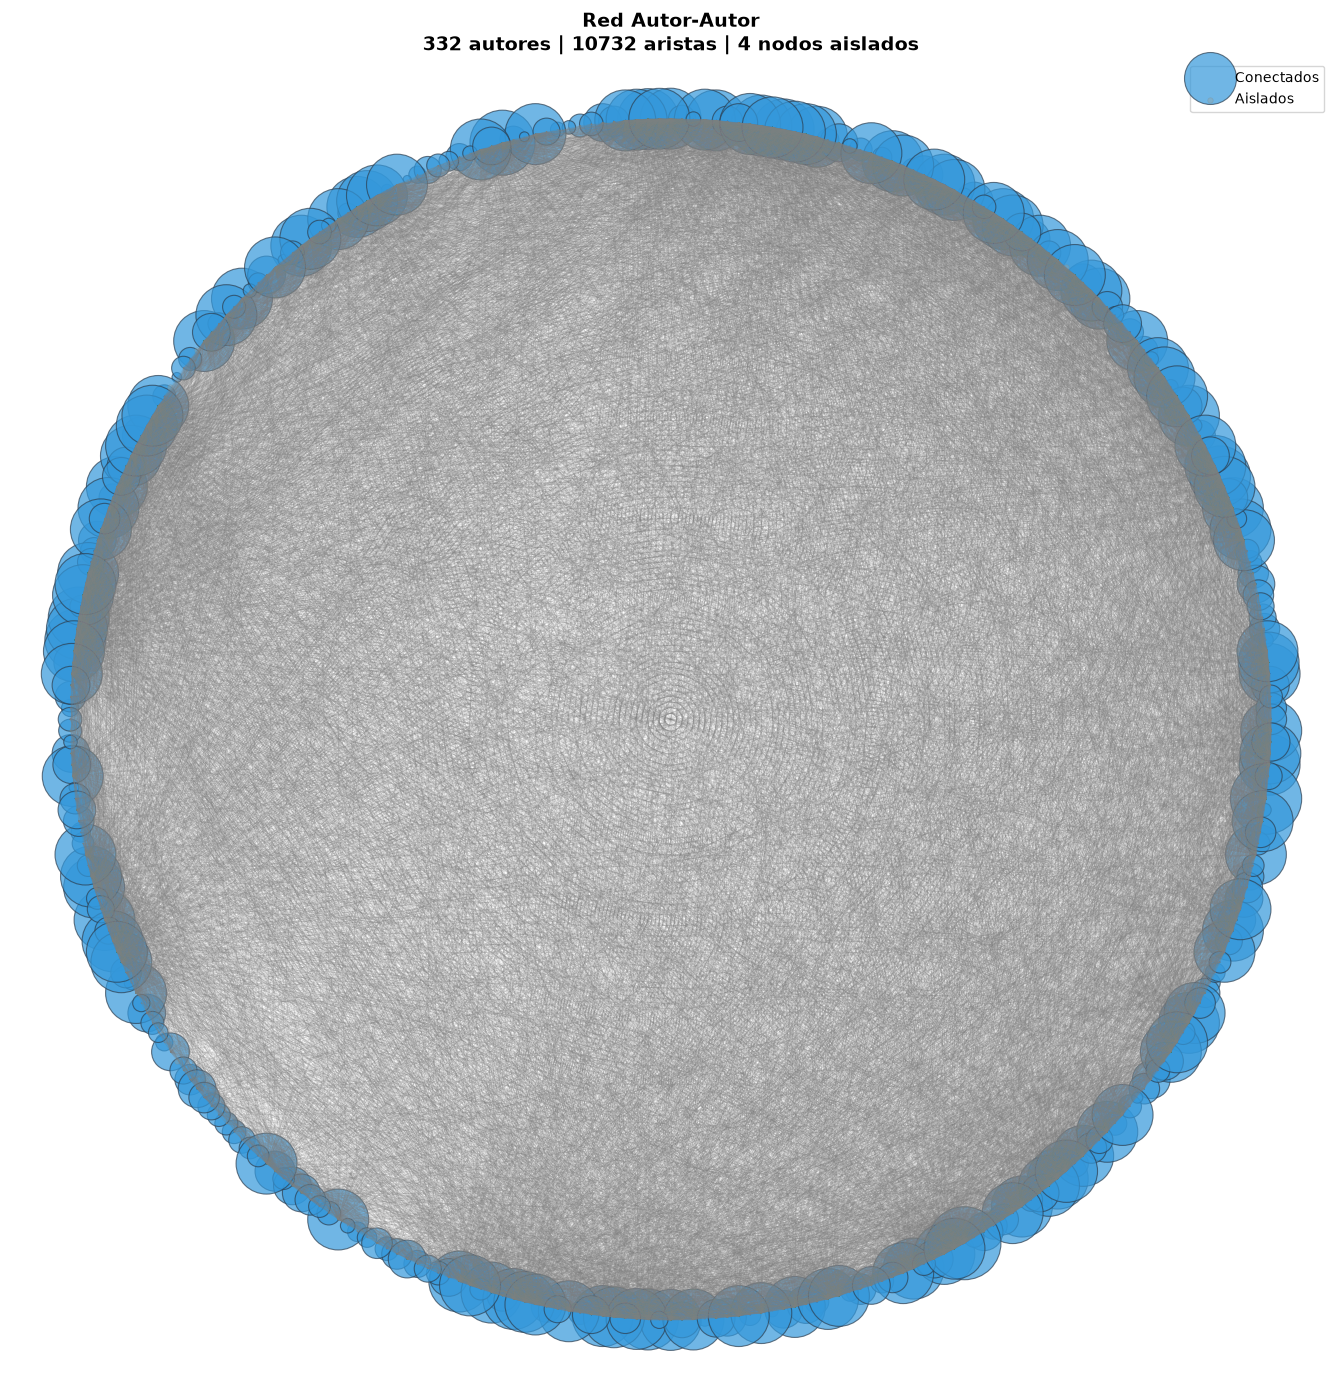

In [32]:
np.random.seed(42)
nodos_set = list(autores['id'].unique())
n_nodos = len(nodos_set)
angulos = np.linspace(0, 2*np.pi, n_nodos, endpoint=False)
posiciones = {n: (np.cos(angulos[i]), np.sin(angulos[i])) for i, n in enumerate(nodos_set)}

fig, ax = plt.subplots(figsize=(16, 14))

for _, row in df_aa.iterrows():
    x1, y1 = posiciones[row['author_1']]
    x2, y2 = posiciones[row['author_2']]
    w = row['weight']
    ax.plot([x1, x2], [y1, y2], 'gray', alpha=0.2, linewidth=0.3 + 0.2*w)

grado_dict = defaultdict(int)
for _, row in df_aa.iterrows():
    grado_dict[row['author_1']] += 1
    grado_dict[row['author_2']] += 1

node_xs_conectados = [posiciones[n][0] for n in nodos_aa_con_aristas]
node_ys_conectados = [posiciones[n][1] for n in nodos_aa_con_aristas]
sizes_conectados = [20 + grado_dict[n]*15 for n in nodos_aa_con_aristas]
ax.scatter(node_xs_conectados, node_ys_conectados, s=sizes_conectados, alpha=0.7, color='#3498db', edgecolors='#2c3e50', linewidth=0.8, label='Conectados')

nodos_aislados_aa = [n for n in nodos_set if n not in nodos_aa_con_aristas]
if len(nodos_aislados_aa) > 0:
    node_xs_aislados = [posiciones[n][0] for n in nodos_aislados_aa]
    node_ys_aislados = [posiciones[n][1] for n in nodos_aislados_aa]
    ax.scatter(node_xs_aislados, node_ys_aislados, s=15, alpha=0.4, color='#95a5a6', edgecolors='#7f8c8d', linewidth=0.5, label='Aislados')

ax.set_title(f'Red Autor-Autor\n{len(autores)} autores | {len(df_aa)} aristas | {n_aislados_aa} nodos aislados', fontsize=14, fontweight='bold')
ax.axis('off')
ax.set_aspect('equal')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('graficos/05_red_autor_autor.png', dpi=150, bbox_inches='tight')
plt.show()



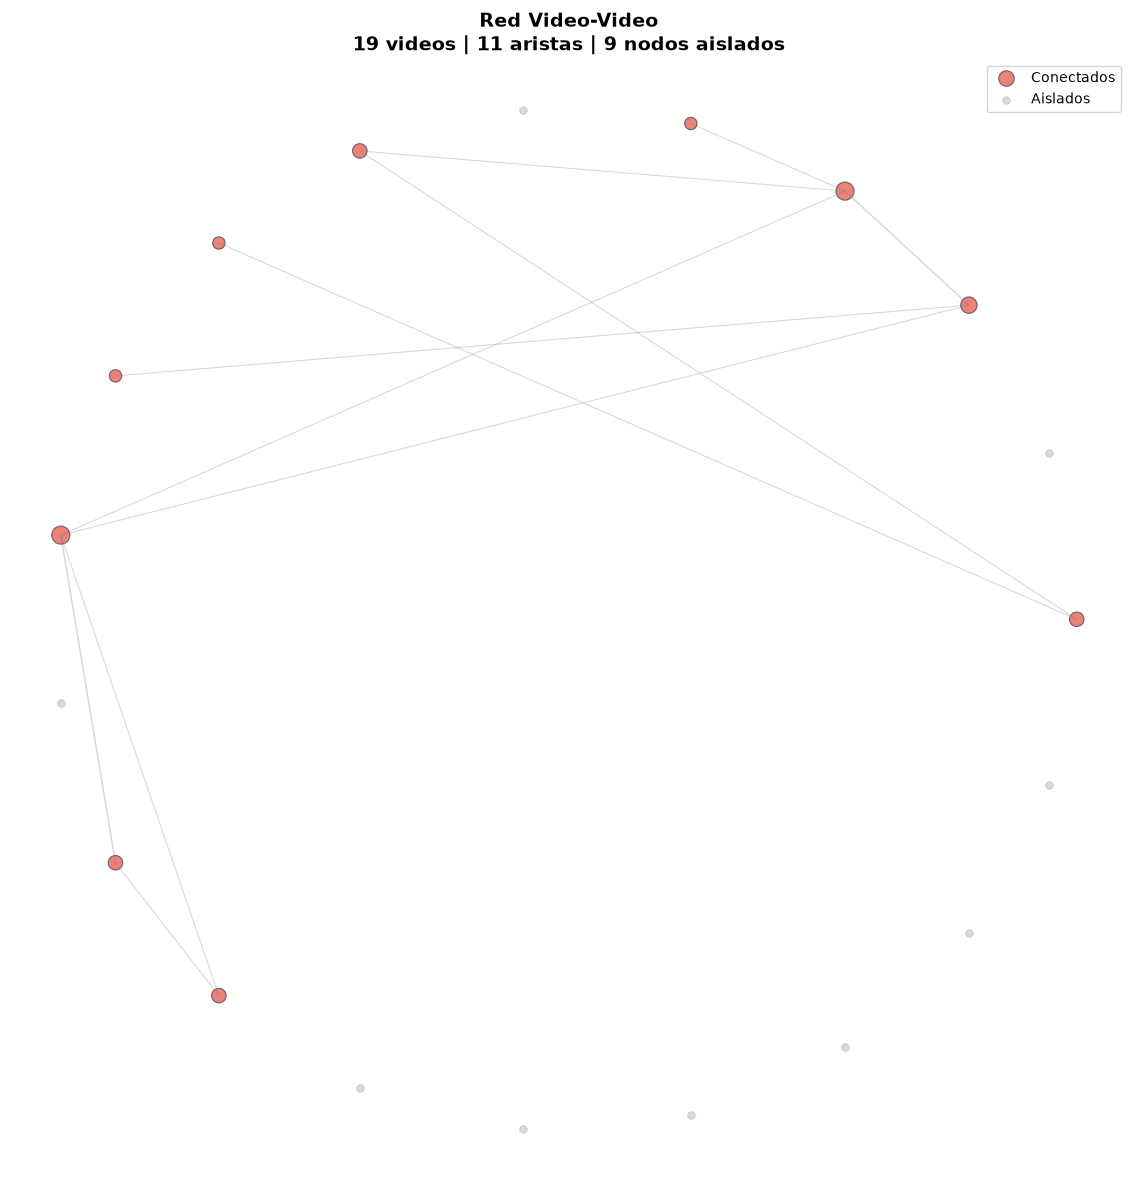

In [33]:
np.random.seed(42)
nodos_set_vv = list(videos['id'].unique())
n_nodos_vv = len(nodos_set_vv)
angulos_vv = np.linspace(0, 2*np.pi, n_nodos_vv, endpoint=False)
posiciones_vv = {n: (np.cos(angulos_vv[i]), np.sin(angulos_vv[i])) for i, n in enumerate(nodos_set_vv)}

fig, ax = plt.subplots(figsize=(14, 12))

grado_dict_vv = defaultdict(int)
for _, row in df_vv.iterrows():
    x1, y1 = posiciones_vv[row['video_1']]
    x2, y2 = posiciones_vv[row['video_2']]
    w = row['weight']
    ax.plot([x1, x2], [y1, y2], 'gray', alpha=0.3, linewidth=0.5 + 0.3*w)
    grado_dict_vv[row['video_1']] += 1
    grado_dict_vv[row['video_2']] += 1

node_xs_conectados_vv = [posiciones_vv[n][0] for n in nodos_vv_con_aristas]
node_ys_conectados_vv = [posiciones_vv[n][1] for n in nodos_vv_con_aristas]
sizes_conectados_vv = [50 + grado_dict_vv[n]*30 for n in nodos_vv_con_aristas]
ax.scatter(node_xs_conectados_vv, node_ys_conectados_vv, s=sizes_conectados_vv, alpha=0.7, color='#e74c3c', edgecolors='#2c3e50', linewidth=0.8, label='Conectados')

nodos_aislados_vv = [n for n in nodos_set_vv if n not in nodos_vv_con_aristas]
if len(nodos_aislados_vv) > 0:
    node_xs_aislados_vv = [posiciones_vv[n][0] for n in nodos_aislados_vv]
    node_ys_aislados_vv = [posiciones_vv[n][1] for n in nodos_aislados_vv]
    ax.scatter(node_xs_aislados_vv, node_ys_aislados_vv, s=30, alpha=0.4, color='#95a5a6', edgecolors='#7f8c8d', linewidth=0.5, label='Aislados')

ax.set_title(f'Red Video-Video\n{len(videos)} videos | {len(df_vv)} aristas | {n_aislados_vv} nodos aislados', fontsize=14, fontweight='bold')
ax.axis('off')
ax.set_aspect('equal')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('graficos/06_red_video_video.png', dpi=150, bbox_inches='tight')
plt.show()



# 6 Análisis Topológico

## 6.1 Métricas Estructurales Básicas

In [197]:
from networkx.algorithms import bipartite
import networkx as nx
from networkx.algorithms import bipartite


In [198]:
def calculate_metrics(G, network_name, is_bipartite=False, partition_set=None):
    metrics = {
        'Red': network_name,
        'Nodos': G.number_of_nodes(),
        'Aristas': G.number_of_edges(),
    }

    if is_bipartite and partition_set is not None:
        metrics['Densidad'] = bipartite.density(G, partition_set)
    else:
        metrics['Densidad'] = nx.density(G)

    metrics['Grado_promedio'] = np.mean([d for n, d in G.degree()])
    metrics['Diametro'] = nx.diameter(G) if nx.is_connected(G) else 'N/A (desconectada)'
    metrics['Numero_componentes'] = nx.number_connected_components(G)

    if is_bipartite:
        metrics['Transitividad'] = np.nan
        clustering_values = bipartite.clustering(G, partition_set)
        metrics['Clustering_bipartito_promedio'] = np.mean(list(clustering_values.values())) if clustering_values else np.nan
    else:
        metrics['Transitividad'] = nx.transitivity(G)
        metrics['Clustering_bipartito_promedio'] = np.nan

    largest_cc = max(nx.connected_components(G), key=len)
    subgraph = G.subgraph(largest_cc)

    if subgraph.number_of_nodes() > 1 and subgraph.number_of_edges() > 0:
        try:
            metrics['Node_connectivity_comp_mayor'] = nx.node_connectivity(subgraph)
        except:
            metrics['Node_connectivity_comp_mayor'] = np.nan
        try:
            metrics['Edge_connectivity_comp_mayor'] = nx.edge_connectivity(subgraph)
        except:
            metrics['Edge_connectivity_comp_mayor'] = np.nan
    else:
        metrics['Node_connectivity_comp_mayor'] = np.nan
        metrics['Edge_connectivity_comp_mayor'] = np.nan

    return metrics

autores_en_bipartita = set(nodos[nodos['tipo'] == 'autor']['id'])
videos_en_bipartita = set(nodos[nodos['tipo'] == 'video']['id'])

metrics_bipartita = calculate_metrics(G_bipartita, 'Bipartita', is_bipartite=True, partition_set=autores_en_bipartita)
metrics_aa = calculate_metrics(G_aa, 'Autor-Autor')
metrics_vv = calculate_metrics(G_vv, 'Video-Video')

metricas_estructurales = pd.DataFrame([metrics_bipartita, metrics_aa, metrics_vv])
metricas_estructurales.to_csv('fase_6_metricas/metricas_estructurales_basicas.csv', index=False)
metricas_estructurales

,Red,Nodos,Aristas,Densidad,Grado_promedio,Diametro,Numero_componentes,Transitividad,Clustering_bipartito_promedio,Node_connectivity_comp_mayor,Edge_connectivity_comp_mayor
0,Bipartita,351,343,0.054375,1.954416,N/A (desconectada),10,NaN,0.942269,1,1
1,Autor-Autor,332,10732,0.195319,64.650602,N/A (desconectada),10,0.984025,NaN,1,5
2,Video-Video,19,11,0.064327,1.157895,N/A (desconectada),10,0.315789,NaN,1,1


## 6.2 Distribuciones de Grados

In [199]:
def extract_degree_stats(G, network_name):
    degrees = [d for n, d in G.degree()]
    return {
        'Red': network_name,
        'Grado_minimo': min(degrees) if degrees else 0,
        'Grado_maximo': max(degrees) if degrees else 0,
        'Grado_promedio': np.mean(degrees) if degrees else 0,
        'Grado_mediana': np.median(degrees) if degrees else 0,
        'Desviacion_estandar': np.std(degrees) if degrees else 0,
        'Nodos_grado_0': sum(1 for d in degrees if d == 0),
        'Nodos_grado_1': sum(1 for d in degrees if d == 1),
    }

stats_list = []
for G, name in [(G_bipartita, 'Bipartita'), (G_aa, 'Autor-Autor'), (G_vv, 'Video-Video')]:
    stats_list.append(extract_degree_stats(G, name))

estadisticas_grados = pd.DataFrame(stats_list)
estadisticas_grados.to_csv('fase_6_metricas/estadisticas_grados_basicas.csv', index=False)
estadisticas_grados

,Red,Grado_minimo,Grado_maximo,Grado_promedio,Grado_mediana,Desviacion_estandar,Nodos_grado_0,Nodos_grado_1
0,Bipartita,1,128,1.954416,1.0,7.705267,0,327
1,Autor-Autor,0,183,64.650602,48.0,51.754444,4,2
2,Video-Video,0,4,1.157895,1.0,1.348026,9,3


In [200]:
autores_en_bipartita = set(nodos[nodos['tipo'] == 'autor']['id'])
videos_en_bipartita = set(nodos[nodos['tipo'] == 'video']['id'])

grados_autores_bipartita = [(node, G_bipartita.degree(node)) for node in autores_en_bipartita]
grados_videos_bipartita = [(node, G_bipartita.degree(node)) for node in videos_en_bipartita]

grados_aa = [(node, G_aa.degree(node)) for node in G_aa.nodes()]
grados_vv = [(node, G_vv.degree(node)) for node in G_vv.nodes()]

distribucion_grados_data = []
for node, deg in grados_autores_bipartita:
    distribucion_grados_data.append({'Red': 'Bipartita-Autores', 'Nodo': node, 'Grado': deg})
for node, deg in grados_videos_bipartita:
    distribucion_grados_data.append({'Red': 'Bipartita-Videos', 'Nodo': node, 'Grado': deg})
for node, deg in grados_aa:
    distribucion_grados_data.append({'Red': 'Autor-Autor', 'Nodo': node, 'Grado': deg})
for node, deg in grados_vv:
    distribucion_grados_data.append({'Red': 'Video-Video', 'Nodo': node, 'Grado': deg})

distribucion_grados = pd.DataFrame(distribucion_grados_data)
distribucion_grados.to_csv('fase_6_metricas/distribucion_grados_completa.csv', index=False)
print(f"Distribución de grados guardada: {len(distribucion_grados)} registros")

Distribución de grados guardada: 702 registros


## 6.3 Análisis de Componentes Conectados

In [201]:
def analyze_components(G, network_name):
    components = list(nx.connected_components(G))
    component_sizes = sorted([len(c) for c in components], reverse=True)
    data = []
    for i, comp_size in enumerate(component_sizes, 1):
        data.append({
            'Red': network_name,
            'Componente': i,
            'Tamano': comp_size,
            'Porcentaje': round(100 * comp_size / G.number_of_nodes(), 2)
        })
    return pd.DataFrame(data)

comp_bipartita = analyze_components(G_bipartita, 'Bipartita')
comp_aa = analyze_components(G_aa, 'Autor-Autor')
comp_vv = analyze_components(G_vv, 'Video-Video')

componentes_completo = pd.concat([comp_bipartita, comp_aa, comp_vv], ignore_index=True)
componentes_completo.to_csv('fase_6_metricas/componentes_analisis.csv', index=False)
componentes_completo

,Red,Componente,Tamano,Porcentaje
0,Bipartita,1,286,81.48
1,Bipartita,2,26,7.41
2,Bipartita,3,19,5.41
3,Bipartita,4,5,1.42
4,Bipartita,5,4,1.14
5,Bipartita,6,3,0.85
6,Bipartita,7,2,0.57
7,Bipartita,8,2,0.57
8,Bipartita,9,2,0.57
9,Bipartita,10,2,0.57


## 6.4 Nodos Aislados y Periféricos

In [202]:
nodos_aislados_aa = [n for n in G_aa.nodes() if G_aa.degree(n) == 0]
nodos_aislados_vv = [n for n in G_vv.nodes() if G_vv.degree(n) == 0]

def get_peripheral_nodes(G, threshold_percentile=25):
    degrees = [d for n, d in G.degree()]
    threshold = np.percentile(degrees, threshold_percentile)
    return [n for n in G.nodes() if 0 < G.degree(n) <= threshold]

perifericos_aa = get_peripheral_nodes(G_aa)
perifericos_vv = get_peripheral_nodes(G_vv)

aislados_data = []
for node in nodos_aislados_aa:
    aislados_data.append({'Red': 'Autor-Autor', 'Nodo': node, 'Grado': 0})
for node in nodos_aislados_vv:
    aislados_data.append({'Red': 'Video-Video', 'Nodo': node, 'Grado': 0})

if aislados_data:
    aislados_df = pd.DataFrame(aislados_data)
    aislados_df.to_csv('nodos_aislados.csv', index=False)
    print(f"Nodos aislados: {len(aislados_data)}")
    aislados_df
else:
    print("No hay nodos aislados")

Nodos aislados: 13


In [203]:
perifericos_data = []
for node in perifericos_aa:
    perifericos_data.append({'Red': 'Autor-Autor', 'Nodo': node, 'Grado': G_aa.degree(node)})
for node in perifericos_vv:
    perifericos_data.append({'Red': 'Video-Video', 'Nodo': node, 'Grado': G_vv.degree(node)})

if perifericos_data:
    perifericos_df = pd.DataFrame(perifericos_data)
    perifericos_df.to_csv('nodos_perifericos.csv', index=False)
    print(f"Nodos periféricos: {len(perifericos_data)}")
    perifericos_df
else:
    print("No hay nodos periféricos")

Nodos periféricos: 94


## 6.5 Visualizaciones

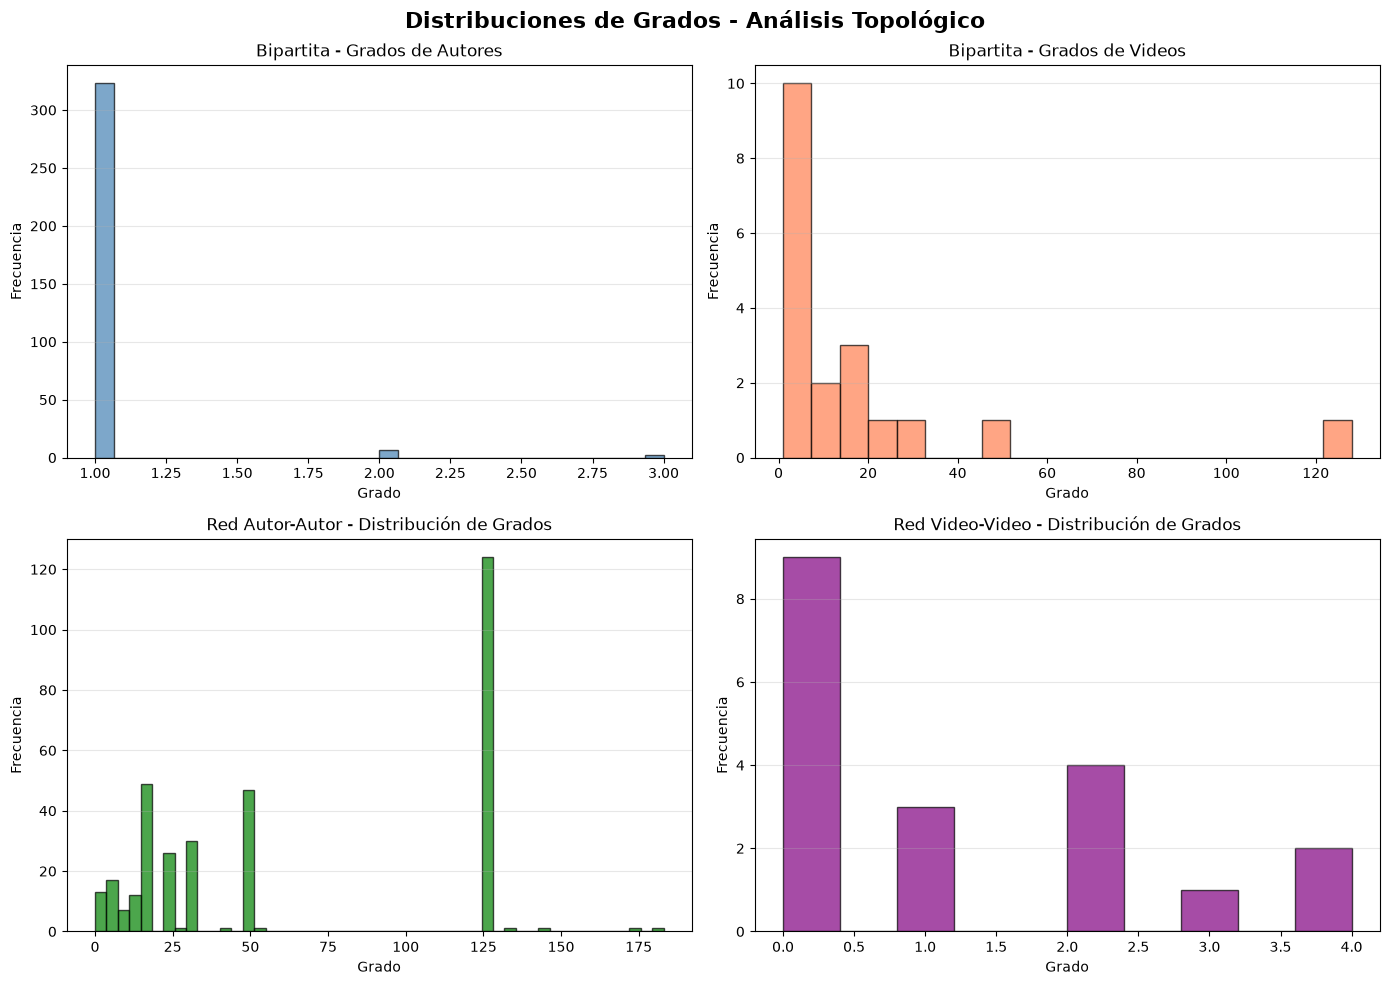

In [204]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribuciones de Grados - Análisis Topológico', fontsize=16, fontweight='bold')

degrees_autores = [G_bipartita.degree(n) for n in autores_en_bipartita]
axes[0, 0].hist(degrees_autores, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Bipartita - Grados de Autores')
axes[0, 0].set_xlabel('Grado')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].grid(axis='y', alpha=0.3)

degrees_videos = [G_bipartita.degree(n) for n in videos_en_bipartita]
axes[0, 1].hist(degrees_videos, bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Bipartita - Grados de Videos')
axes[0, 1].set_xlabel('Grado')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].grid(axis='y', alpha=0.3)

degrees_aa_list = [G_aa.degree(n) for n in G_aa.nodes()]
axes[1, 0].hist(degrees_aa_list, bins=50, color='green', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Red Autor-Autor - Distribución de Grados')
axes[1, 0].set_xlabel('Grado')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].grid(axis='y', alpha=0.3)

degrees_vv_list = [G_vv.degree(n) for n in G_vv.nodes()]
axes[1, 1].hist(degrees_vv_list, bins=10, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Red Video-Video - Distribución de Grados')
axes[1, 1].set_xlabel('Grado')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('graficos/06_distribucion_grados.png', dpi=300, bbox_inches='tight')
plt.show()

## 6.6 Tabla Resumen

In [205]:
resumen_data = []

for tipo, nodes_set in [('Autores', autores_en_bipartita), ('Videos', videos_en_bipartita)]:
    degrees = [G_bipartita.degree(n) for n in nodes_set]
    resumen_data.append({
        'Red': 'Bipartita',
        'Tipo_Nodo': tipo,
        'Cantidad': len(nodes_set),
        'Grado_min': min(degrees),
        'Grado_max': max(degrees),
        'Grado_prom': round(np.mean(degrees), 2),
        'Grado_mediana': np.median(degrees),
    })

degrees_aa = [G_aa.degree(n) for n in G_aa.nodes()]
resumen_data.append({
    'Red': 'Autor-Autor',
    'Tipo_Nodo': 'Autores',
    'Cantidad': G_aa.number_of_nodes(),
    'Grado_min': min(degrees_aa),
    'Grado_max': max(degrees_aa),
    'Grado_prom': round(np.mean(degrees_aa), 2),
    'Grado_mediana': np.median(degrees_aa),
})

degrees_vv = [G_vv.degree(n) for n in G_vv.nodes()]
resumen_data.append({
    'Red': 'Video-Video',
    'Tipo_Nodo': 'Videos',
    'Cantidad': G_vv.number_of_nodes(),
    'Grado_min': min(degrees_vv),
    'Grado_max': max(degrees_vv),
    'Grado_prom': round(np.mean(degrees_vv), 2),
    'Grado_mediana': np.median(degrees_vv),
})

resumen_topologia = pd.DataFrame(resumen_data)
resumen_topologia.to_csv('fase_6_metricas/resumen_topologia_redes.csv', index=False)
resumen_topologia

,Red,Tipo_Nodo,Cantidad,Grado_min,Grado_max,Grado_prom,Grado_mediana
0,Bipartita,Autores,332,1,3,1.03,1.0
1,Bipartita,Videos,19,1,128,18.05,7.0
2,Autor-Autor,Autores,332,0,183,64.65,48.0
3,Video-Video,Videos,19,0,4,1.16,1.0


## 6.7 Validación de Control

In [206]:
assert G_bipartita.number_of_nodes() == len(nodos), "Bipartite nodes mismatch"
assert G_aa.number_of_nodes() == len(nodos_aa_full), "Author-author nodes mismatch"
assert G_vv.number_of_nodes() == len(nodos_vv_full), "Video-video nodes mismatch"

assert G_bipartita.number_of_edges() == len(aristas), "Bipartite edges mismatch"
assert G_aa.number_of_edges() == len(aristas_aa_full), "Author-author edges mismatch"
assert G_vv.number_of_edges() == len(aristas_vv_full), "Video-video edges mismatch"

print("All control assertions passed")
print("Phase 6 analysis complete")

All control assertions passed
Phase 6 analysis complete


In [220]:
G_aa = nx.Graph()

G_aa.add_nodes_from(
    nodos_aa_full['author_channel_id']
)

for _, row in aristas_aa_full.iterrows():
    G_aa.add_edge(
        row['author_1'],
        row['author_2'],
        weight=row['weight']
    )

print("Nodos:", G_aa.number_of_nodes())
print("Aristas:", G_aa.number_of_edges())

weights_aa = [
    data['weight']
    for _, _, data in G_aa.edges(data=True)
]

print("Peso mínimo:", min(weights_aa))
print("Peso máximo:", max(weights_aa))
print("Aristas con peso:", len(weights_aa))

Nodos: 332
Aristas: 10732
Peso mínimo: 1
Peso máximo: 2
Aristas con peso: 10732


## 7. Comunidades

### 7.1 Selección de red

In [221]:
from networkx.algorithms import community

communities_raw = list(community.louvain_communities(
    G_aa,
    weight='weight',
    resolution=1,
    seed=42
))

communities_sorted = sorted(communities_raw, key=len, reverse=True)

community_map_stable = {}
for comm_id, comm in enumerate(communities_sorted, 1):
    for node in comm:
        community_map_stable[node] = comm_id

print(f'Comunidades detectadas: {len(communities_sorted)}')
for i, comm in enumerate(communities_sorted, 1):
    print(f'  Comunidad {i}: {len(comm)} nodos ({100*len(comm)/332:.1f}%)')

Comunidades detectadas: 14
  Comunidad 1: 126 nodos (38.0%)
  Comunidad 2: 61 nodos (18.4%)
  Comunidad 3: 55 nodos (16.6%)
  Comunidad 4: 28 nodos (8.4%)
  Comunidad 5: 25 nodos (7.5%)
  Comunidad 6: 18 nodos (5.4%)
  Comunidad 7: 6 nodos (1.8%)
  Comunidad 8: 4 nodos (1.2%)
  Comunidad 9: 3 nodos (0.9%)
  Comunidad 10: 2 nodos (0.6%)
  Comunidad 11: 1 nodos (0.3%)
  Comunidad 12: 1 nodos (0.3%)
  Comunidad 13: 1 nodos (0.3%)
  Comunidad 14: 1 nodos (0.3%)


### 7.2 Cálculo de modularidad

In [222]:
modularity = nx.algorithms.community.modularity(
    G_aa,
    [set(c) for c in communities_sorted],
    weight='weight'
)

print(f'Modularidad: {modularity:.4f}')

Modularidad: 0.3949


### 7.3 Asignación de autores a comunidades

In [223]:
autores_list = []

for author_id in nodos_aa_full['author_channel_id']:
    author_info = nodos_aa_full[nodos_aa_full['author_channel_id'] == author_id].iloc[0]
    comm_id = community_map_stable[author_id]
    comm_size = len(communities_sorted[comm_id - 1])

    autores_list.append({
        'author_channel_id': author_id,
        'community_id': comm_id,
        'community_size': comm_size,
        'grado_aa': author_info['grado'],
        'author_name': author_info['author_name'],
        'n_comentarios': author_info['n_comentarios'],
        'n_videos': author_info['n_videos']
    })

df_autores_comm = pd.DataFrame(autores_list)

df_tamanos_comm = pd.DataFrame([
    {'community_id': i, 'size': len(communities_sorted[i-1]), 'percentage': round(100*len(communities_sorted[i-1])/332, 2)}
    for i in range(1, len(communities_sorted) + 1)
])

df_tamanos_comm.to_csv('fase_7_comunidades/tamanos_comunidades.csv', index=False)
df_autores_comm.to_csv('fase_7_comunidades/autores_comunidades.csv', index=False)

print(f'Autores asignados: {len(df_autores_comm)}')
df_autores_comm.head(10)

Autores asignados: 332


,author_channel_id,community_id,community_size,grado_aa,author_name,n_comentarios,n_videos
0,UC-HeUTT6_g-VoiWds2a4H-w,2,61,31,@JorgeMunoz-gd9et,1.0,1.0
1,UC-Iul5tDYH_oiAMXQH-KaaQ,2,61,31,@AlbertoMancilla-p9h,1.0,1.0
2,UC-QOpE7GOxlXcHZ8b7HbQKA,6,18,17,@mariaalexander427,2.0,1.0
3,UC-fiZBS5Gp1eCJd9ucgWnCg,3,55,48,@Tommii.10,1.0,1.0
4,UC-hfX8J5JPJ-dfuakzegMLA,1,126,127,@normaleticiaorozcojuarez2418,1.0,1.0
5,UC-jS_kA9w-OmpupXDx156Rg,1,126,127,@simoncreyesc7579,1.0,1.0
6,UC-pNP6RMFuLg_-x7Ah_0kEA,1,126,127,@almacatalan2717,1.0,1.0
7,UC094EFEmMSdwVa8NQjjYBXg,7,6,6,@CelestinoQuej-j7k,1.0,1.0
8,UC0HvfEWozTHbwl_iEmJNvVA,2,61,31,@OttoPalencia-b7r,1.0,1.0
9,UC0RpuMwkDKJYqgKHtsJRuWQ,5,25,24,@sabinamarinaguerra3248,1.0,1.0


### 7.4 Resumen de comunidades

In [224]:
resumen = []

for comm_id in range(1, len(communities_sorted) + 1):
    comm_autores = df_autores_comm[df_autores_comm['community_id'] == comm_id]

    resumen.append({
        'community_id': comm_id,
        'numero_autores': len(comm_autores),
        'total_comentarios': comm_autores['n_comentarios'].sum(),
        'promedio_comentarios': round(comm_autores['n_comentarios'].mean(), 2),
        'total_videos': comm_autores['n_videos'].sum(),
        'promedio_videos': round(comm_autores['n_videos'].mean(), 2),
        'grado_promedio_aa': round(comm_autores['grado_aa'].mean(), 2),
        'grado_maximo': comm_autores['grado_aa'].max(),
        'grado_minimo': comm_autores['grado_aa'].min()
    })

df_resumen_comm = pd.DataFrame(resumen)
df_resumen_comm.to_csv('fase_7_comunidades/resumen_comunidades.csv', index=False)

top3_ids = df_resumen_comm['community_id'].head(3).tolist()
df_resumen_principales = df_resumen_comm[df_resumen_comm['community_id'].isin(top3_ids)].copy()
df_resumen_principales.to_csv('fase_7_comunidades/resumen_comunidades_principales.csv', index=False)

df_resumen_comm

,community_id,numero_autores,total_comentarios,promedio_comentarios,total_videos,promedio_videos,grado_promedio_aa,grado_maximo,grado_minimo
0,1,126,161.0,1.28,128.0,1.02,127.19,145,127
1,2,61,83.0,1.36,63.0,1.03,24.13,49,12
2,3,55,60.0,1.09,59.0,1.07,48.27,183,6
3,4,28,33.0,1.18,31.0,1.11,12.46,28,5
4,5,25,25.0,1.00,25.0,1.00,24.00,24,24
5,6,18,25.0,1.39,18.0,1.00,17.00,17,17
6,7,6,6.0,1.00,6.0,1.00,6.00,6,6
7,8,4,4.0,1.00,4.0,1.00,3.00,3,3
8,9,3,3.0,1.00,3.0,1.00,2.00,2,2
9,10,2,2.0,1.00,2.0,1.00,1.00,1,1


### 7.5 Top autores por comunidad

In [225]:
top_autores_list = []

for comm_id in range(1, len(communities_sorted) + 1):
    comm_autores = df_autores_comm[df_autores_comm['community_id'] == comm_id]
    top_5 = comm_autores.nlargest(5, 'n_comentarios')

    for rank, (_, row) in enumerate(top_5.iterrows(), 1):
        top_autores_list.append({
            'community_id': comm_id,
            'ranking': rank,
            'author_channel_id': row['author_channel_id'],
            'author_name': row['author_name'],
            'n_comentarios': row['n_comentarios'],
            'n_videos': row['n_videos'],
            'grado_aa': row['grado_aa']
        })

df_top_autores_comm = pd.DataFrame(top_autores_list)
df_top_autores_comm.to_csv('fase_7_comunidades/top_autores_por_comunidad.csv', index=False)

print(f'Top autores registrados: {len(df_top_autores_comm)}')
df_top_autores_comm.head(15)

Top autores registrados: 48


,community_id,ranking,author_channel_id,author_name,n_comentarios,n_videos,grado_aa
0,1,1,UC5H8ASmMC9WrURmzeB4ySog,@ManuelEdran,5.0,1.0,127
1,1,2,UC9vMq1YF-e7C-VO0SHkbUTA,@ErvinLeonardoCarreraLatín,4.0,1.0,127
2,1,3,UC3XTwHxygNCgjndsg-UiCQA,@marioajset4283,3.0,1.0,127
3,1,4,UC72gBAtyb_VXQlYDcFrh6oQ,@osmanmorales3012,3.0,1.0,127
4,1,5,UCFjudnPLoaSL1BaRuLahyHg,@HaroldoCastillo-rh9iw,3.0,1.0,127
5,2,1,UCyJhqmMbsvjpoarBBStA2kg,@Murmullodelbarrio,6.0,1.0,31
6,2,2,UCV3fr-YOixFKCZBbJP1-X4w,@albertoshernandez5251,5.0,1.0,31
7,2,3,UCNIeXbV_mEwpa412h1aqUWw,@juandeleon9060,3.0,1.0,18
8,2,4,UCg3eIfd7BrsLEqS0BLkftHA,@ErmePérez-q4s,3.0,1.0,18
9,2,5,UC7IMsCxfZyWN7YQo8-JYa6Q,@Burgos68,2.0,1.0,18


###  Top videos por comunidad

In [226]:
print(videos.columns.tolist())
print(videos.head())

['id', 'bipartite', 'tipo', 'nombre', 'n_comentarios', 'n_videos', 'titulo', 'canal', 'categoria']
              id bipartite   tipo nombre  n_comentarios  n_videos  \
332  6W4u8sGEnGM     video  video    NaN            NaN       NaN   
333  OkXlHx0hx-8     video  video    NaN            NaN       NaN   
334  j43HgwYFKfk     video  video    NaN            NaN       NaN   
335  n8iP75gIpmw     video  video    NaN            NaN       NaN   
336  b_Hkrkl3adA     video  video    NaN            NaN       NaN   

                                                titulo  \
332  Inician los trabajos de recuperación del Puent...   
333  EE.UU. envía a mexicanos deportados a Guatemal...   
334      La cooptación de Walter Mazariegos en la USAC   
335                          Qué rico come tu diputado   
336  Bloqueos en Guatemala este 31 de agosto por al...   

                                     canal        categoria  
332  Gobierno de la República de Guatemala    Entertainment  
333          

In [227]:
nodos_videos_comm = nodos[nodos['tipo'] == 'video'].set_index('id')

top_videos_list = []

for comm_id in range(1, len(communities_sorted) + 1):
    comm_autores_ids = set(
        df_autores_comm[
            df_autores_comm['community_id'] == comm_id
        ]['author_channel_id']
    )

    aristas_comm = aristas[
        aristas['autor'].isin(comm_autores_ids)
    ]

    conteo_videos = (
        aristas_comm
        .groupby('video')['autor']
        .nunique()
        .sort_values(ascending=False)
        .head(5)
    )

    for rank, (video_id, n_autores) in enumerate(conteo_videos.items(), 1):
        if video_id in nodos_videos_comm.index:
            video_info = nodos_videos_comm.loc[video_id]

            top_videos_list.append({
                'community_id': comm_id,
                'ranking': rank,
                'video_id': video_id,
                'titulo': video_info['titulo'],
                'canal': video_info['canal'],
                'categoria': video_info['categoria'],
                'n_autores_comunidad': n_autores
            })

df_top_videos_comm = pd.DataFrame(top_videos_list)

df_top_videos_comm.to_csv(
    'fase_7_comunidades/top_videos_por_comunidad.csv',
    index=False
)

print(f'Top videos registrados: {len(df_top_videos_comm)}')

df_top_videos_comm.head(15)

Top videos registrados: 23


,community_id,ranking,video_id,titulo,canal,categoria,n_autores_comunidad
0,1,1,n8iP75gIpmw,Qué rico come tu diputado,Quorum,News & Politics,126
1,1,2,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala,Entertainment,1
2,1,3,b_Hkrkl3adA,Bloqueos en Guatemala este 31 de agosto por al...,PrensaLibreOficial,News & Politics,1
3,2,1,6W4u8sGEnGM,Inician los trabajos de recuperación del Puent...,Gobierno de la República de Guatemala,Entertainment,32
4,2,2,PjmxCj-a9Hg,Conferencia de Prensa del Gobierno de Guatemal...,Gobierno de la República de Guatemala,Entertainment,18
5,2,3,06mFNPU0aB8,Capturan a presuntos delincuentes disfrazados ...,Noti7,News & Politics,13
6,3,1,j43HgwYFKfk,La cooptación de Walter Mazariegos en la USAC,Quorum,News & Politics,49
7,3,2,is3Mk5oC19g,Capturan a ladrón que había quedado grabado mi...,TN23 Guatemala,News & Politics,7
8,3,3,n8iP75gIpmw,Qué rico come tu diputado,Quorum,News & Politics,2
9,3,4,ndAZjHqzzT8,Internet: escoger el menos malo,Quorum,News & Politics,1


###  Top canales por comunidad

In [228]:
top_canales_list = []

for comm_id in range(1, len(communities_sorted) + 1):
    comm_autores_ids = set(
        df_autores_comm[
            df_autores_comm['community_id'] == comm_id
        ]['author_channel_id']
    )

    aristas_comm = aristas[
        aristas['autor'].isin(comm_autores_ids)
    ].copy()

    aristas_comm = aristas_comm.merge(
        nodos[
            nodos['tipo'] == 'video'
        ][['id', 'canal', 'categoria']],
        left_on='video',
        right_on='id',
        how='left'
    )

    resumen_canales = (
        aristas_comm
        .groupby('canal')
        .agg(
            n_videos=('video', 'nunique'),
            n_participaciones=('video', 'size'),
            n_autores=('autor', 'nunique')
        )
        .reset_index()
        .sort_values(
            ['n_participaciones', 'n_videos'],
            ascending=False
        )
        .head(5)
    )

    for rank, (_, row) in enumerate(resumen_canales.iterrows(), 1):
        top_canales_list.append({
            'community_id': comm_id,
            'ranking': rank,
            'canal': row['canal'],
            'n_videos': row['n_videos'],
            'n_participaciones': row['n_participaciones'],
            'n_autores': row['n_autores']
        })

df_top_canales_comm = pd.DataFrame(top_canales_list)

df_top_canales_comm.to_csv(
    'fase_7_comunidades/top_canales_por_comunidad.csv',
    index=False
)

print(f'Top canales registrados: {len(df_top_canales_comm)}')

df_top_canales_comm.head(15)

Top canales registrados: 18


,community_id,ranking,canal,n_videos,n_participaciones,n_autores
0,1,1,Quorum,1,126,126
1,1,2,Gobierno de la República de Guatemala,1,1,1
2,1,3,PrensaLibreOficial,1,1,1
3,2,1,Gobierno de la República de Guatemala,2,50,49
4,2,2,Noti7,1,13,13
5,3,1,Quorum,3,52,49
6,3,2,TN23 Guatemala,1,7,7
7,4,1,Quorum,3,31,28
8,5,1,Municipalidad de Guatemala,1,25,25
9,6,1,Noticias Telemundo,1,18,18


### Análisis de temas frecuentes

In [229]:
from collections import Counter

comments = pd.read_csv('comments_clean.csv')

comments_comm = comments.merge(
    df_autores_comm[
        ['author_channel_id', 'community_id']
    ],
    on='author_channel_id',
    how='inner'
)

temas_frecuentes_list = []

for comm_id in range(1, len(communities_sorted) + 1):
    textos = (
        comments_comm[
            comments_comm['community_id'] == comm_id
        ]['texto_limpio']
        .dropna()
        .astype(str)
    )

    tokens = []

    for texto in textos:
        palabras = [
            palabra.strip()
            for palabra in texto.split()
            if len(palabra.strip()) > 2
        ]
        tokens.extend(palabras)

    if tokens:
        frecuencias_palabras = Counter(tokens)

        for rank, (termino, frecuencia) in enumerate(
            frecuencias_palabras.most_common(10),
            1
        ):
            temas_frecuentes_list.append({
                'community_id': comm_id,
                'tipo': 'palabra',
                'termino': termino,
                'frecuencia': frecuencia,
                'ranking': rank
            })

        bigramas_comunidad = []

        for texto in textos:
            palabras = [
                palabra.strip()
                for palabra in texto.split()
                if len(palabra.strip()) > 2
            ]

            if len(palabras) >= 2:
                bigramas_texto = zip(palabras, palabras[1:])
                bigramas_comunidad.extend(
                    [' '.join(bigrama) for bigrama in bigramas_texto]
                )

        frecuencias_bigramas = Counter(bigramas_comunidad)

        for rank, (termino, frecuencia) in enumerate(
            frecuencias_bigramas.most_common(10),
            1
        ):
            temas_frecuentes_list.append({
                'community_id': comm_id,
                'tipo': 'bigrama',
                'termino': termino,
                'frecuencia': frecuencia,
                'ranking': rank
            })

df_temas_comm = pd.DataFrame(temas_frecuentes_list)

df_temas_comm.to_csv(
    'fase_7_comunidades/temas_frecuentes_por_comunidad.csv',
    index=False
)

print(f'Temas frecuentes registrados: {len(df_temas_comm)}')

df_temas_comm.head(40)

Temas frecuentes registrados: 239


,community_id,tipo,termino,frecuencia,ranking
0,1,palabra,pueblo,50,1
1,1,palabra,diputado,48,2
2,1,palabra,pagar,36,3
3,1,palabra,hacer,35,4
4,1,palabra,dinero,27,5
5,1,palabra,trabajo,21,6
6,1,palabra,decir,21,7
7,1,palabra,sueldo,20,8
8,1,palabra,cara,19,9
9,1,palabra,dar,18,10


###  Visualización de la red completa

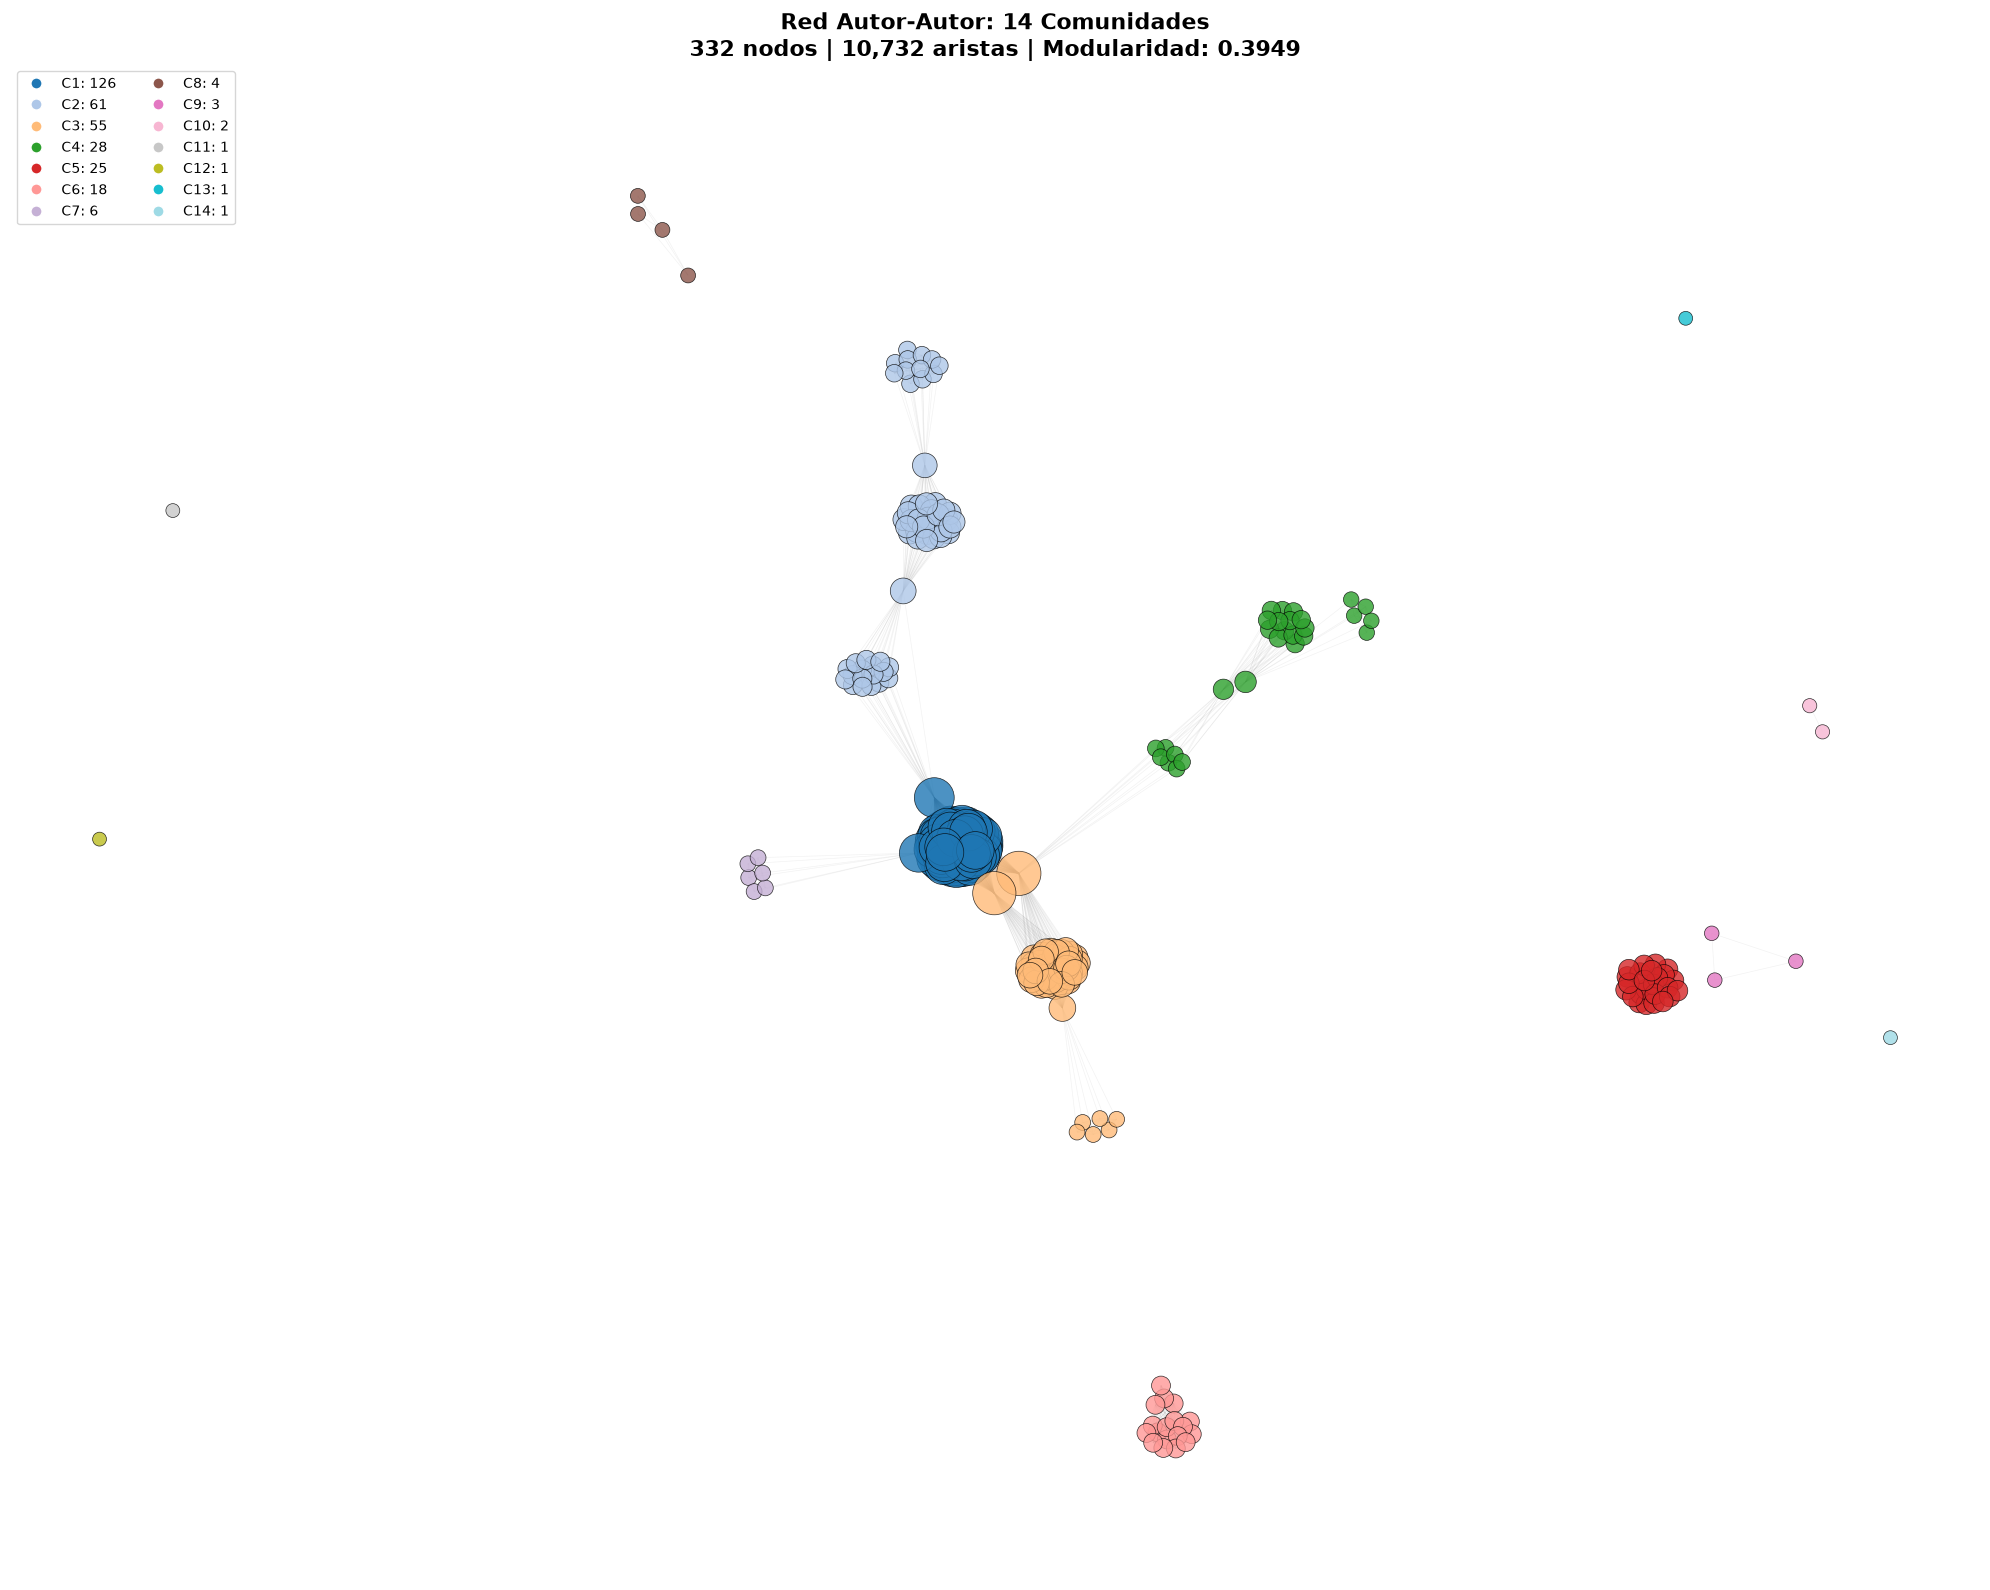

In [230]:
fig, ax = plt.subplots(figsize=(20, 16))

pos = nx.spring_layout(G_aa, k=0.1, iterations=50, seed=42)

colors = plt.cm.tab20(np.linspace(0, 1, len(communities_sorted)))
node_colors_list = [colors[community_map_stable[node] - 1] for node in G_aa.nodes()]

node_sizes = [100 + 5 * G_aa.degree(node) for node in G_aa.nodes()]

nx.draw_networkx_edges(G_aa, pos, alpha=0.1, width=0.5, edge_color='gray', ax=ax)

nx.draw_networkx_nodes(
    G_aa,
    pos,
    node_color=node_colors_list,
    node_size=node_sizes,
    alpha=0.8,
    ax=ax,
    edgecolors='black',
    linewidths=0.5
)

ax.set_title(f'Red Autor-Autor: {len(communities_sorted)} Comunidades\n332 nodos | 10,732 aristas | Modularidad: {modularity:.4f}',
             fontsize=16, fontweight='bold')
ax.axis('off')

legend_elements = []
for i, color in enumerate(colors[:len(communities_sorted)]):
    size = len(communities_sorted[i])
    legend_elements.append(
        plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                   markersize=8, label=f'C{i+1}: {size}')
    )
ax.legend(handles=legend_elements, loc='upper left', fontsize=10, ncol=2)

plt.tight_layout()
plt.savefig('graficos/07_red_comunidades_autor_autor.png', dpi=150, bbox_inches='tight')
plt.show()

##### Validación

In [231]:
assert G_aa.number_of_nodes() == 332, "G_aa debe tener 332 nodos"
assert G_aa.number_of_edges() == 10732, "G_aa debe tener 10732 aristas"
assert len(df_autores_comm) == 332, "Deben asignarse todos los 332 autores"
assert all(df_autores_comm['community_id'].isin(range(1, len(communities_sorted) + 1))), "community_id inconsistente"
assert -1 <= modularity <= 1, f"Modularidad inválida: {modularity}"

print(f'Comunidades: {len(communities_sorted)}')
print(f'Autores asignados: {len(df_autores_comm)}')
print(f'Modularidad: {modularity:.4f}')



Comunidades: 14
Autores asignados: 332
Modularidad: 0.3949


In [232]:
print(aristas_aa_full.columns.tolist())
print(aristas_aa_full.head())

['author_1', 'author_2', 'weight']
                   author_1                  author_2  weight
0  UC-HeUTT6_g-VoiWds2a4H-w  UC-Iul5tDYH_oiAMXQH-KaaQ       1
1  UC-HeUTT6_g-VoiWds2a4H-w  UC0HvfEWozTHbwl_iEmJNvVA       1
2  UC-HeUTT6_g-VoiWds2a4H-w  UC14qlobYKqD-DO0j6b75lcA       1
3  UC-HeUTT6_g-VoiWds2a4H-w  UC1NiEdJ7gk6FlDexIalWnGg       1
4  UC-HeUTT6_g-VoiWds2a4H-w  UC3YpzAr7pcdKC7BVFEpYzog       1


In [235]:
import os

weights_aa = [
    data['weight']
    for _, _, data in G_aa.edges(data=True)
]

assert G_aa.number_of_nodes() == 332
assert G_aa.number_of_edges() == 10732

assert len(weights_aa) == 10732
assert min(weights_aa) == 1
assert max(weights_aa) == 2

assert len(df_autores_comm) == 332
assert df_autores_comm['author_channel_id'].nunique() == 332
assert df_autores_comm['community_id'].notna().all()

assert df_tamanos_comm['size'].sum() == 332

assert len(
    [n for n in G_aa.nodes() if G_aa.degree(n) == 0]
) == 4

assert -1 <= modularity <= 1

assert os.path.exists('fase_7_comunidades/temas_frecuentes_por_comunidad.csv')

print("Validaciones hechas")

Validaciones hechas


In [237]:
import sys
!{sys.executable} -m pip install pysentimiento

     -------------------------------------- 389.2/389.2 kB 3.0 MB/s eta 0:00:00
     ------------------------------------- 559.1/559.1 kB 11.9 MB/s eta 0:00:00
     ------------------------------------- 124.1/124.1 MB 12.1 MB/s eta 0:00:00
     --------------------------------------- 12.1/12.1 MB 31.2 MB/s eta 0:00:00
     ---------------------------------------- 158.8/158.8 kB ? eta 0:00:00
     ------------------------------------- 796.8/796.8 kB 52.4 MB/s eta 0:00:00
     ---------------------------------------- 355.5/355.5 kB ? eta 0:00:00
     ---------------------------------------- 100.0/100.0 kB ? eta 0:00:00
     --------------------------------------- 27.9/27.9 MB 28.4 MB/s eta 0:00:00
     -------------------------------------- 120.0/120.0 kB 7.3 MB/s eta 0:00:00
     -------------------------------------- 144.5/144.5 kB 8.4 MB/s eta 0:00:00
     ---------------------------------------- 203.9/203.9 kB ? eta 0:00:00
  Using cached setuptools-84.0.0-py3-none-any.whl (818 kB)
 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [238]:
from pysentimiento import create_analyzer

analyzer = create_analyzer(
    task="sentiment",
    lang="es"
)

print("pysentimiento cargado correctamente")

c:\Users\belen\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\belen\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\belen\.cache\huggingface\hub\models--pysentimiento--robertuito-sentiment-analysis. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or 

pysentimiento cargado correctamente


In [239]:
muestra = comments[['comment_id', 'texto_original']].dropna().head(3).copy()

for _, row in muestra.iterrows():
    resultado = analyzer.predict(row['texto_original'])

    print("Comentario:", row['comment_id'])
    print("Texto:", row['texto_original'])
    print("Sentimiento:", resultado.output)
    print("Probabilidades:", resultado.probas)
    print("-" * 60)

Comentario: Ugw-J65a1iYL9hqhELh4AaABAg
Texto: Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel
Sentimiento: NEG
Probabilidades: {'NEG': 0.8077868819236755, 'NEU': 0.14628511667251587, 'POS': 0.04592809081077576}
------------------------------------------------------------
Comentario: Ugw-ZT9t9wU2V-tCaUZ4AaABAg
Texto: Están jóvenes porque no buscan un trabajo,  tuvieron suerte que no hay policías que le gusta del otro vando , por ir vestido de mujer se los hubieran ensamblado la maquinaria.
Sentimiento: NEG
Probabilidades: {'NEG': 0.9650870561599731, 'NEU': 0.029080351814627647, 'POS': 0.005832502152770758}
------------------------------------------------------------
Comentario: Ugw0xaOb2CYXXoudtwJ4AaABAg
Texto: Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es una maquila
Sentimiento: NEG
Probabilidades: {'NEG': 0.9713771343231201, 'NEU': 0.025966867804527283, 'POS': 0.002656027674674988}
--------------------------------------

In [240]:
from tqdm.auto import tqdm

sentimientos = []

for _, row in tqdm(comments.iterrows(), total=len(comments)):
    texto = row['texto_original']

    if pd.isna(texto) or not str(texto).strip():
        sentimientos.append({
            'comment_id': row['comment_id'],
            'sentimiento': np.nan,
            'prob_NEG': np.nan,
            'prob_NEU': np.nan,
            'prob_POS': np.nan
        })
        continue

    resultado = analyzer.predict(str(texto))

    sentimientos.append({
        'comment_id': row['comment_id'],
        'sentimiento': resultado.output,
        'prob_NEG': resultado.probas['NEG'],
        'prob_NEU': resultado.probas['NEU'],
        'prob_POS': resultado.probas['POS']
    })

df_sentimiento = pd.DataFrame(sentimientos)

df_sentimiento.to_csv(
    'fase_7_comunidades/sentimiento_comentarios.csv',
    index=False
)

print(df_sentimiento['sentimiento'].value_counts(dropna=False))
print(df_sentimiento.head())

100%|██████████| 406/406 [00:28<00:00, 14.12it/s]

sentimiento
NEG    250
POS     80
NEU     76
Name: count, dtype: int64
                   comment_id sentimiento  prob_NEG  prob_NEU  prob_POS
0  Ugw-J65a1iYL9hqhELh4AaABAg         NEG  0.807787  0.146285  0.045928
1  Ugw-ZT9t9wU2V-tCaUZ4AaABAg         NEG  0.965087  0.029080  0.005833
2  Ugw0xaOb2CYXXoudtwJ4AaABAg         NEG  0.971377  0.025967  0.002656
3  Ugw0xgUc2ISpBr5_T654AaABAg         NEG  0.701865  0.267648  0.030487
4  Ugw1ZzA21njWhaqQQTh4AaABAg         NEG  0.804465  0.175605  0.019930


In [ ]:
comments_sent = comments.merge(
    df_sentimiento,
    on='comment_id',
    how='left'
)

comments_sent = comments_sent.merge(
    df_autores_comm[
        ['author_channel_id', 'community_id']
    ],
    on='author_channel_id',
    how='left'
)

resumen_sentimiento_comunidad = (
    comments_sent
    .dropna(subset=['community_id', 'sentimiento'])
    .groupby(['community_id', 'sentimiento'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ['NEG', 'NEU', 'POS']:
    if col not in resumen_sentimiento_comunidad.columns:
        resumen_sentimiento_comunidad[col] = 0

resumen_sentimiento_comunidad['total'] = (
    resumen_sentimiento_comunidad['NEG'] +
    resumen_sentimiento_comunidad['NEU'] +
    resumen_sentimiento_comunidad['POS']
)

resumen_sentimiento_comunidad['pct_NEG'] = (
    100 * resumen_sentimiento_comunidad['NEG'] /
    resumen_sentimiento_comunidad['total']
).round(2)

resumen_sentimiento_comunidad['pct_NEU'] = (
    100 * resumen_sentimiento_comunidad['NEU'] /
    resumen_sentimiento_comunidad['total']
).round(2)

resumen_sentimiento_comunidad['pct_POS'] = (
    100 * resumen_sentimiento_comunidad['POS'] /
    resumen_sentimiento_comunidad['total']
).round(2)

resumen_sentimiento_comunidad.to_csv('fase_7_comunidades/sentimiento_por_comunidad.csv', index=False )

resumen_sentimiento_comunidad.head(14)

sentimiento,community_id,NEG,NEU,POS,total,pct_NEG,pct_NEU,pct_POS
0,1,131,21,9,161,81.37,13.04,5.59
1,2,38,25,20,83,45.78,30.12,24.10
2,3,37,12,11,60,61.67,20.00,18.33
3,4,17,7,9,33,51.52,21.21,27.27
4,5,2,3,20,25,8.00,12.00,80.00
5,6,16,6,3,25,64.00,24.00,12.00
6,7,5,1,0,6,83.33,16.67,0.00
7,8,1,0,3,4,25.00,0.00,75.00
8,9,1,0,2,3,33.33,0.00,66.67
9,10,1,1,0,2,50.00,50.00,0.00
